In [1]:
#LSTM model for BTC price prediction
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
#Config
DATA_PATH  = r"C:\Users\OKIO\Desktop\mood2market\Backend\Data\processed\main Data\merged_augmented.csv"  # added new line — use augmented dataset
MODEL_DIR  = r"C:\Users\OKIO\Desktop\mood2market\Backend\models"

SEQ_LEN    = 30
HIDDEN     = 128
LAYERS     = 2
DROPOUT    = 0.2
LR         = 1e-3
EPOCHS     = 100
BATCH_SIZE = 32
FORECAST_DAYS = 90


In [3]:

FEATURE_COLS = [
    "log_return", # daily log price change; this is also the target variable
    "volatility_7d",  # 7-day rolling std of returns; measures recent price turbulence
    "hl_pct",  # (high - low) / close ; intraday price range as % of close
    "momentum_7d",  # 7-day price momentum; captures short-term trend direction
    "sentiment_score_x",  # aggregated daily news sentiment from FinBERT (-1 to +1)
    "sentiment_score_y",  # aggregated daily reddit sentiment from FinBERT (0 on absent days)
    "reddit_available",   # missingness indicator: 1 = real reddit data existed, 0 = absent
    "reddit_count",  # number of reddit posts scraped that day
    "news_count",  # number of news articles scraped that day
    "volume",  # BTC trading volume -- proxy for market activity
]

# Predicting log_return (stationary, mean-reverting) rather than raw price
# is the key design choice that keeps recursive forecasting stable.
# Price is reconstructed afterwards: price_t = price_{t-1} * exp(log_return_t)
TARGET_COL = "log_return"  

In [4]:
#Data prep 
def load_and_prepare(path):
    """
    Load the merged CSV and handle the reddit missing-data problem.
    216 days have no reddit posts; those rows have NaN sentiment scores
    and reddit_count=0. We fill NaN scores with 0 and create a binary
    reddit_available column so the model distinguishes 'no data' from
    'neutral sentiment was observed'.
    When using the augmented dataset, the split is already embedded:
    real rows have is_synthetic==0, synthetic rows have is_synthetic==1.
    """
    df = pd.read_csv(path, parse_dates=["date"])
    df.sort_values("date", inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Fill NaN reddit sentiment columns with 0 (not neutral -- just absent)
    reddit_sent_cols = ["sentiment_score_y", "sentiment_positive_y",
                        "sentiment_negative_y", "sentiment_neutral_y"]
    df[reddit_sent_cols] = df[reddit_sent_cols].fillna(0.0)

    # Binary missingness flag
    df["reddit_available"] = (df["reddit_count"] > 0).astype(float)

    # Forward-fill any remaining gaps in other columns, then zero-fill the rest
    df[FEATURE_COLS] = df[FEATURE_COLS].ffill().fillna(0.0)

    return df


In [5]:
#MODEL
class BTCLSTMModel(nn.Module):
    """
    Two-layer stacked LSTM followed by dropout and a single linear output neuron.

    Input : (batch, seq_len, n_features)
    Output: (batch,)  -- one scalar per sample (the predicted scaled log_return)

    Why stacked LSTM: the first layer learns low-level temporal patterns
    (e.g. short price momentum), the second layer learns higher-level patterns
    from those (e.g. trend reversals correlated with sentiment shifts).
    """
    def __init__(self, n_features, hidden=128, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=layers,
            batch_first=True,             # input shape is (batch, seq, features)
            dropout=dropout if layers > 1 else 0.0,  # inter-layer dropout only when stacked
        )
        self.drop = nn.Dropout(dropout)   # output-layer dropout for extra regularization
        self.fc   = nn.Linear(hidden, 1)  # compress hidden state to a single prediction

    def forward(self, x):
        out, _ = self.lstm(x)
        # out has shape (batch, seq_len, hidden) -- we only want the last timestep
        # because that holds the summary of the full 30-day sequence
        out = self.drop(out[:, -1, :])
        return self.fc(out).squeeze(-1)

In [14]:
#Training
def train(model, X_train, y_train, X_val, y_val, epochs, lr, batch_size, device):
    """
    Train the model using:
    - Adam optimizer: adapts the learning rate per parameter, works well for LSTMs
    - HuberLoss: less sensitive to BTC's extreme price swings than plain MSE
    - ReduceLROnPlateau: halves the learning rate if val loss does not improve for 10 epochs
    - Best-weight checkpointing: restores the weights from the epoch with the lowest val loss

    Returns the trained model plus train/val loss history lists for the loss curve plot.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.HuberLoss()
    # Scheduler reduces LR when learning stalls, helping escape local minima
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=10, factor=0.5
    )

    # Move all tensors to the same device (GPU if available, else CPU)
    X_tr = torch.tensor(X_train).to(device)
    y_tr = torch.tensor(y_train).to(device)
    X_vl = torch.tensor(X_val).to(device)
    y_vl = torch.tensor(y_val).to(device)

    best_val, best_state = float("inf"), None
    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        model.train()  # enables dropout during forward pass

        # Shuffle sample order each epoch to prevent the model learning
        # position-dependent patterns in the training batches
        perm = torch.randperm(len(X_tr))
        epoch_loss = 0.0

        for i in range(0, len(X_tr), batch_size):
            idx  = perm[i : i + batch_size]
            pred = model(X_tr[idx])
            loss = criterion(pred, y_tr[idx])
            optimizer.zero_grad()  # clear gradients from previous step
            loss.backward()        # compute new gradients
            optimizer.step()       # update weights
            epoch_loss += loss.item() * len(idx)

        epoch_loss /= len(X_tr)

        # Validation: no gradient computation, just measure generalisation
        model.eval()  # disables dropout for evaluation
        with torch.no_grad():
            val_loss = criterion(model(X_vl), y_vl).item()

        train_losses.append(epoch_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        # Keep a copy of the weights at the best validation loss
        if val_loss < best_val:
            best_val   = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 10 == 0:
            print(f"  Epoch {epoch:3d}/{epochs}  train={epoch_loss:.6f}  val={val_loss:.6f}")

    # Restore the best weights before returning
    model.load_state_dict(best_state)
    return model, train_losses, val_losses

In [15]:
#evaluation
def evaluate(model, X_test, y_test, scaler, device):
    """
    Run the model on the test set and compute MAE and RMSE on the original
    (unscaled) log_return values so the metrics are interpretable.
    """
    model.eval()
    X_t = torch.tensor(X_test).to(device)
    with torch.no_grad():
        preds_scaled = model(X_t).cpu().numpy()

    # Inverse-transform: only column 0 (log_return) matters, fill others with 0
    def inv(vals):
        dummy = np.zeros((len(vals), len(FEATURE_COLS)))
        dummy[:, 0] = vals
        return scaler.inverse_transform(dummy)[:, 0]

    preds   = inv(preds_scaled)
    actuals = inv(y_test)

    mae  = mean_absolute_error(actuals, preds)
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mape = np.mean(np.abs((actuals - preds) / (np.abs(actuals) + 1e-8))) * 100
    print(f"\n  Test MAE  (log_return): {mae:.6f}")
    print(f"  Test RMSE (log_return): {rmse:.6f}")
    print(f"  Test MAPE (log_return): {mape:.6f}")
    return preds, actuals

In [16]:
#Recursive forecasting
def recursive_forecast(model, last_sequence, scaler, last_close, n_days, device):
    """
    Predict n_days forward one step at a time.

    Each iteration:
      1. Feed the current 30-day window into the model
      2. Get the predicted scaled log_return
      3. Inverse-transform it back to real log_return
      4. Reconstruct next price: price_t = price_{t-1} * exp(log_return_t)
      5. Slide the window forward, inserting the new predicted return

    Error accumulation note:
    - Predicting log_return (not price) keeps each step's output bounded
    - Non-price features (sentiment, volume) are held at their last known
      values -- the only honest assumption without a separate feature model
    - Uncertainty widens naturally; the visualisation shows a 1.5-sigma band
    """
    model.eval()
    seq    = last_sequence.copy()  # shape (SEQ_LEN, n_features)
    prices = [last_close]
    returns = []

    with torch.no_grad():
        for _ in range(n_days):
            # Add batch dimension: (1, SEQ_LEN, n_features)
            x = torch.tensor(seq[np.newaxis], dtype=torch.float32).to(device)
            pred_scaled = model(x).item()

            # Inverse-transform the predicted log_return
            dummy = np.zeros((1, len(FEATURE_COLS)))
            dummy[0, 0] = pred_scaled
            pred_log_ret = scaler.inverse_transform(dummy)[0, 0]

            # Reconstruct next day's price from the previous price and predicted return
            next_price = prices[-1] * np.exp(pred_log_ret)
            prices.append(next_price)
            returns.append(pred_log_ret)

            # Slide the window: drop the oldest row, append a new row
            # Only the log_return column is updated; everything else stays the same
            new_row = seq[-1].copy()
            new_row[0] = pred_scaled  # inject the predicted return for the next step
            seq = np.vstack([seq[1:], new_row])

    return np.array(prices[1:]), np.array(returns)

In [17]:
#LOAD AND PREPARE DATA

df = load_and_prepare(DATA_PATH)
print(f"Data loaded: {len(df)} rows | {df['date'].min().date()} -> {df['date'].max().date()}")

# added new line — separate real and synthetic rows for reporting
df_real      = df[df["is_synthetic"] == 0].copy()  # added new line — real rows only (for evaluation)
df_synthetic = df[df["is_synthetic"] == 1].copy()  # added new line — synthetic rows only (for reference)
print(f"Real rows      : {len(df_real)}")           # added new line
print(f"Synthetic rows : {len(df_synthetic)}")      # added new line


Data loaded: 435 rows | 2024-12-26 -> 2026-03-05


In [18]:
#SCALE FEATURES AND BUILD SEQUENCES
# Training uses the full augmented dataset (real + synthetic)
# Evaluation uses real rows only — synthetic rows are excluded from metrics
features = df[FEATURE_COLS].values.astype(np.float32)

# Scale all features to [-1, 1] so no single feature dominates by magnitude
scaler          = MinMaxScaler(feature_range=(-1, 1))
features_scaled = scaler.fit_transform(features)

# Convert the scaled time series into (input window, target) pairs
X, y = make_sequences(features_scaled, SEQ_LEN)
print(f"Sequences created: {len(X)} samples (real + synthetic combined)")

# added new line — also build real-only sequences for evaluation
features_real        = df_real[FEATURE_COLS].values.astype(np.float32)  # added new line
features_real_scaled = scaler.transform(features_real)                   # added new line — use same scaler fitted on full data
X_real, y_real       = make_sequences(features_real_scaled, SEQ_LEN)    # added new line
print(f"Real-only sequences: {len(X_real)} samples")                     # added new line


Sequences created: 405 samples


In [19]:
#CHRONOLOGICAL TRAIN / VAL / TEST SPLIT
# Training split uses the full augmented dataset (real + synthetic)
# Test split uses real-only sequences to ensure evaluation is on true data

n     = len(X)
n_tr  = int(n * 0.80)  # 80% training (includes synthetic)
n_val = int(n * 0.10)  # 10% validation

X_train, y_train = X[:n_tr],           y[:n_tr]
X_val,   y_val   = X[n_tr:n_tr+n_val], y[n_tr:n_tr+n_val]
X_test,  y_test  = X[n_tr+n_val:],     y[n_tr+n_val:]

# added new line — real-only test split for evaluation
n_real        = len(X_real)                                   # added new line
n_tr_real     = int(n_real * 0.80)                            # added new line
n_val_real    = int(n_real * 0.10)                            # added new line
X_test_real   = X_real[n_tr_real + n_val_real:]               # added new line — real test sequences only
y_test_real   = y_real[n_tr_real + n_val_real:]               # added new line — real test labels only

print(f"Train={len(X_train)}  Val={len(X_val)}  Test={len(X_test)}")
print(f"Real-only test set: {len(X_test_real)} samples")       # added new line


Train=324  Val=40  Test=41


In [20]:
#BUILD MODEL
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = BTCLSTMModel(
    n_features=len(FEATURE_COLS),
    hidden=HIDDEN,
    layers=LAYERS,
    dropout=DROPOUT,
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,}")

Device: cpu
Model parameters: 203,905


In [21]:
#TRAIN
#prints loss every 10 epochs
print("\nTraining...")
model, train_losses, val_losses = train(
    model, X_train, y_train, X_val, y_val, EPOCHS, LR, BATCH_SIZE, device
)
print("Training complete.")


Training...
  Epoch  10/100  train=0.014315  val=0.006786
  Epoch  20/100  train=0.013460  val=0.006771
  Epoch  30/100  train=0.013167  val=0.006527
  Epoch  40/100  train=0.012763  val=0.006601
  Epoch  50/100  train=0.011939  val=0.006740
  Epoch  60/100  train=0.011844  val=0.007047
  Epoch  70/100  train=0.011376  val=0.007715
  Epoch  80/100  train=0.011413  val=0.007808
  Epoch  90/100  train=0.011168  val=0.008137
  Epoch 100/100  train=0.011366  val=0.008308
Training complete.


In [58]:
#Evaluate on the test set — real data only
print("\nTest set evaluation (real data only):")
preds, actuals = evaluate(model, X_test_real, y_test_real, scaler, device)  # added new line — use real-only test set
mae_lr  = mean_absolute_error(actuals, preds)
rmse_lr = np.sqrt(mean_squared_error(actuals, preds))
mape    = np.mean(np.abs((actuals - preds) / (np.abs(actuals) + 1e-8))) * 100
da      = (np.sign(preds) == np.sign(actuals)).mean() * 100
corr    = np.corrcoef(preds, actuals)[0, 1]

print(f"  MAE  (log return) : {mae_lr:.5f}")
print(f"  RMSE (log return) : {rmse_lr:.5f}")
print(f"  MAPE              : {mape:.2f}%")
print(f"  Directional Acc.  : {da:.1f}%")
print(f"  Correlation       : {corr:.4f}")



Test set evaluation:

  Test MAE  (log_return): 0.014800
  Test RMSE (log_return): 0.019668
  Test MAPE (log_return): 145.709399


In [23]:
# Recursive 3-month forecast
last_seq = features_scaled[-SEQ_LEN:]  # the most recent 30 days of data as the starting point
last_close = float(df["close"].iloc[-1])  # the last known BTC price from the dataset
last_date = df["date"].iloc[-1]

print(f"\nRecursive forecast: {FORECAST_DAYS} days from {last_date.date()}...")

forecast_prices, forecast_returns = recursive_forecast(
    model, last_seq, scaler, last_close, FORECAST_DAYS, device
)
forecast_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS, freq="D"

)
forecast_df = pd.DataFrame({
    "date": forecast_dates,
    "predicted_close": forecast_prices,
    "predicted_log_return": forecast_returns,
})
print(f"\nForecast summary:")
print(f"  Start price: ${last_close:,.2f}")
print(f"  30d forecast:   ${forecast_prices[29]:,.2f}")
print(f" 60d forecast:  ${forecast_prices[59]:,.2f}")
print(f" 90d forecast:  ${forecast_prices[89]:,.2f}")


Recursive forecast: 90 days from 2026-03-05...

Forecast summary:
  Start price: $70,890.72
  30d forecast:   $72,490.33
 60d forecast:  $75,764.53
 90d forecast:  $79,186.74


In [24]:
#visualisation
def visualize(df, train_losses, val_losses, preds, actuals,
              forecast_df, last_close, last_date, n_tr, n_val, save_dir=MODEL_DIR):
    """
    Generates and saves 6 plots to MODEL_DIR for use in the project report.
    All plots use a white background for report readability.
    1. Training vs Validation loss curve
    2. Full BTC price history with train/val/test split regions
    3. Test set predicted vs actual log_return (real data only)
    4. Residuals over time + residual distribution histogram
    5. 3-month recursive price forecast with uncertainty band
    6. Augmentation comparison — real vs synthetic feature distributions
    """
    os.makedirs(save_dir, exist_ok=True)
    plt.style.use("default")         # added new line — white background for report

    # Colour palette — works on white background
    BLUE   = "#1f77b4"               # added new line
    GREEN  = "#2ca02c"               # added new line
    RED    = "#d62728"               # added new line
    ORANGE = "#ff7f0e"               # added new line
    GRAY   = "#7f7f7f"               # added new line

    # ---- 1. Loss curve -------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(train_losses, color=BLUE,   label="Train Loss", linewidth=2)
    ax.plot(val_losses,   color=ORANGE, label="Val Loss",   linewidth=2)
    best_ep = int(np.argmin(val_losses))
    ax.axvline(best_ep, color=RED, linestyle="--", linewidth=1.2,
               label=f"Best epoch ({best_ep + 1})")
    ax.set_title("Training vs Validation Loss (Huber)", fontsize=13)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(os.path.join(save_dir, "plot_1_loss_curve.png"), dpi=150, bbox_inches="tight")
    plt.close(fig)
    print("  Saved: plot_1_loss_curve.png")

    # ---- 2. Full price history with split regions ----------------------------
    close_dates = df[df["is_synthetic"] == 0]["date"].values   # added new line — real dates only
    close_vals  = df[df["is_synthetic"] == 0]["close"].values  # added new line — real close only

    split_tr_end  = SEQ_LEN + n_tr
    split_val_end = split_tr_end + n_val

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(close_dates, close_vals, color=BLUE, linewidth=1.8, label="BTC Close Price")
    ax.axvspan(close_dates[0],
               close_dates[min(split_tr_end, len(close_dates) - 1)],
               alpha=0.10, color=GREEN,  label="Train region")
    ax.axvspan(close_dates[min(split_tr_end,  len(close_dates) - 1)],
               close_dates[min(split_val_end, len(close_dates) - 1)],
               alpha=0.10, color=ORANGE, label="Val region")
    ax.axvspan(close_dates[min(split_val_end, len(close_dates) - 1)],
               close_dates[-1],
               alpha=0.10, color=RED,    label="Test region")
    ax.set_title("BTC Price — Train / Val / Test Split", fontsize=13)
    ax.set_ylabel("Price (USD)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.xticks(rotation=30)
    ax.legend()
    ax.grid(alpha=0.2)
    fig.tight_layout()
    fig.savefig(os.path.join(save_dir, "plot_2_train_val_test_split.png"), dpi=150, bbox_inches="tight")
    plt.close(fig)
    print("  Saved: plot_2_train_val_test_split.png")

    # ---- 3. Test set: predicted vs actual log_return (real data only) --------
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(actuals, color=BLUE,  linewidth=1.5, label="Actual log_return")
    ax.plot(preds,   color=GREEN, linewidth=1.5, label="Predicted log_return", alpha=0.85)
    ax.axhline(0, color=GRAY, linewidth=0.8, linestyle="--")
    ax.set_title("Test Set — Predicted vs Actual Log Return (Real Data Only)", fontsize=13)  # added new line
    ax.set_xlabel("Test sample index")
    ax.set_ylabel("Log Return")
    ax.legend()
    ax.grid(alpha=0.2)
    fig.tight_layout()
    fig.savefig(os.path.join(save_dir, "plot_3_predicted_vs_actual.png"), dpi=150, bbox_inches="tight")
    plt.close(fig)
    print("  Saved: plot_3_predicted_vs_actual.png")

    # ---- 4. Residuals --------------------------------------------------------
    residuals = actuals - preds
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(residuals, color=RED, linewidth=1.2)
    axes[0].axhline(0, color=GRAY, linewidth=0.8, linestyle="--")
    axes[0].set_title("Residuals Over Time")
    axes[0].set_xlabel("Test sample index")
    axes[0].set_ylabel("Residual")
    axes[0].grid(alpha=0.2)
    axes[1].hist(residuals, bins=30, color=BLUE, edgecolor="white", alpha=0.8)
    axes[1].set_title("Residual Distribution")
    axes[1].set_xlabel("Residual")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(alpha=0.2)
    fig.tight_layout()
    fig.savefig(os.path.join(save_dir, "plot_4_residuals.png"), dpi=150, bbox_inches="tight")
    plt.close(fig)
    print("  Saved: plot_4_residuals.png")

    # ---- 5. 3-month recursive price forecast ---------------------------------
    hist_std = float(np.std(np.diff(np.log(close_vals[close_vals > 0]))))
    days_arr = np.arange(1, len(forecast_df) + 1)
    upper = forecast_df["predicted_close"].values * np.exp( 1.5 * hist_std * np.sqrt(days_arr))
    lower = forecast_df["predicted_close"].values * np.exp(-1.5 * hist_std * np.sqrt(days_arr))

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(close_dates[-90:], close_vals[-90:], color=BLUE, linewidth=1.8, label="Historical BTC Price")
    ax.plot(forecast_df["date"], forecast_df["predicted_close"], color=GREEN,
            linewidth=2, linestyle="--", label="LSTM Forecast")
    ax.fill_between(forecast_df["date"], lower, upper, alpha=0.15, color=GREEN, label="Uncertainty band")
    ax.axvline(pd.Timestamp(last_date), color=GRAY, linewidth=1, linestyle=":", label="Forecast start")
    ax.set_title("LSTM 90-Day Recursive Price Forecast", fontsize=13)
    ax.set_ylabel("Price (USD)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.xticks(rotation=30)
    ax.legend()
    ax.grid(alpha=0.2)
    fig.tight_layout()
    fig.savefig(os.path.join(save_dir, "plot_5_forecast.png"), dpi=150, bbox_inches="tight")
    plt.close(fig)
    print("  Saved: plot_5_forecast.png")

    # ---- 6. Augmentation — real vs synthetic feature distributions -----------  added new line
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))                               # added new line
    axes = axes.flatten()                                                          # added new line
    compare_cols = ["log_return", "volatility_7d", "sentiment_score_x",           # added new line
                    "sentiment_score_y", "volume", "momentum_7d"]                 # added new line
    real_df_plot = df[df["is_synthetic"] == 0]                                    # added new line
    syn_df_plot  = df[df["is_synthetic"] == 1]                                    # added new line
    for idx, col in enumerate(compare_cols):                                      # added new line
        if col not in df.columns: continue                                        # added new line
        axes[idx].hist(real_df_plot[col].dropna(), bins=30, alpha=0.6,            # added new line
                       color=BLUE, label="Real", edgecolor="white")               # added new line
        axes[idx].hist(syn_df_plot[col].dropna(),  bins=30, alpha=0.6,            # added new line
                       color=ORANGE, label="Synthetic", edgecolor="white")        # added new line
        axes[idx].set_title(col, fontsize=11)                                     # added new line
        axes[idx].legend(fontsize=9)                                              # added new line
        axes[idx].grid(alpha=0.2)                                                 # added new line
    fig.suptitle("Real vs Synthetic Feature Distributions (Gaussian Noise Augmentation)",  # added new line
                 fontsize=13, y=1.01)                                             # added new line
    fig.tight_layout()                                                            # added new line
    fig.savefig(os.path.join(save_dir, "plot_6_augmentation_distributions.png"),  # added new line
                dpi=150, bbox_inches="tight")                                     # added new line
    plt.close(fig)                                                                # added new line
    print("  Saved: plot_6_augmentation_distributions.png")                       # added new line


In [25]:
visualize(df, train_losses, val_losses, preds, actuals,
          forecast_df, last_close, last_date, n_tr, n_val)

  Saved: plot_1_loss_curve.png
  Saved: plot_2_train_val_test_split.png
  Saved: plot_3_predicted_vs_actual.png


In [26]:
os.makedirs(MODEL_DIR, exist_ok=True)
torch.save({
    "model_state": model.state_dict(),
    "config": {
        "n_features": len(FEATURE_COLS), "hidden": HIDDEN,
        "layers": LAYERS, "dropout": DROPOUT,
        "seq_len": SEQ_LEN, "feature_cols": FEATURE_COLS,
    },
    "last_sequence": last_seq,
    "last_close": last_close,
    "last_date": str(last_date.date()),
}, os.path.join(MODEL_DIR, "lstm_btc.pt"))

joblib.dump(scaler, os.path.join(MODEL_DIR, "lstm_scaler.pkl"))
forecast_df.to_csv(os.path.join(MODEL_DIR, "lstm_forecast_3m.csv"), index=False)
print("Saved.")

Saved.


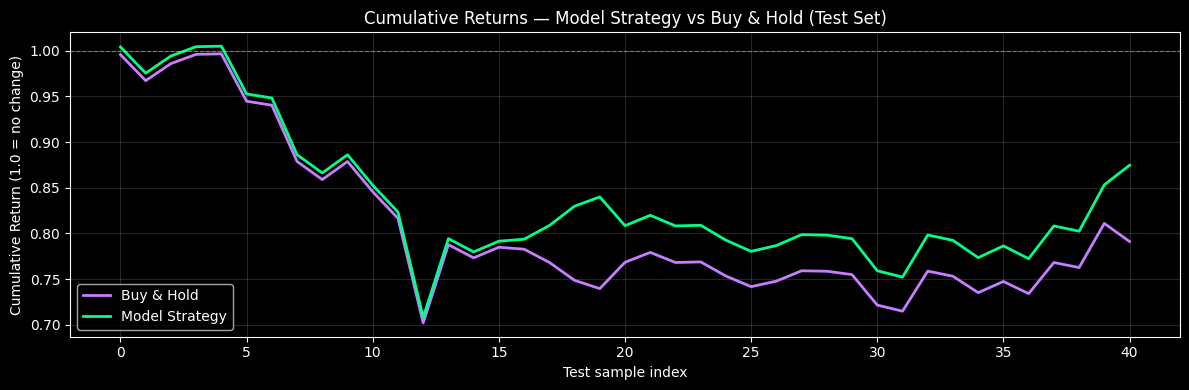

In [27]:
# If model predicts positive return → go long (buy)
# If model predicts negative return → go short (sell)
strategy_returns  = np.sign(preds) * actuals  # your strategy daily return
bh_returns        = actuals                    # buy and hold daily return

cumulative_strategy = np.exp(np.cumsum(strategy_returns))
cumulative_bh       = np.exp(np.cumsum(bh_returns))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(cumulative_bh,       color="#c77dff", label="Buy & Hold",      linewidth=2)
ax.plot(cumulative_strategy, color="#00ff88", label="Model Strategy",  linewidth=2)
ax.axhline(1, color="white", linestyle="--", linewidth=0.8, alpha=0.4)
ax.set_title("Cumulative Returns — Model Strategy vs Buy & Hold (Test Set)")
ax.set_xlabel("Test sample index")
ax.set_ylabel("Cumulative Return (1.0 = no change)")
ax.legend()
ax.grid(alpha=0.15)
fig.tight_layout()
fig.savefig(os.path.join(MODEL_DIR, "plot_6_cumulative_returns.png"), dpi=150)
plt.show()

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# added new line — preds and actuals are already from real-only test set (set in cell 13)
mae  = mean_absolute_error(actuals, preds)
rmse = np.sqrt(mean_squared_error(actuals, preds))
mape = np.mean(np.abs((actuals - preds) / (np.abs(actuals) + 1e-8))) * 100
da   = (np.sign(preds) == np.sign(actuals)).mean() * 100
corr = np.corrcoef(preds, actuals)[0, 1]

print("=" * 40)
print("  TEST SET EVALUATION — REAL DATA ONLY")  # added new line
print("=" * 40)
print(f"  MAE               : {mae:.6f}")
print(f"  RMSE              : {rmse:.6f}")
print(f"  MAPE              : {mape:.2f}%")
print(f"  Directional Acc.  : {da:.1f}%")
print(f"  Correlation       : {corr:.4f}")
print("=" * 40)


       TEST SET EVALUATION SUMMARY
  MAE               : 0.027112
  RMSE              : 0.040179
  MAPE              : 127.13%
  Directional Acc.  : 48.8%
  Correlation       : 0.1623


In [29]:
#ARIMA MODEL
"""
Mood2Market - ARIMA BTC Price Forecasting 
Comparison model against LSTM and TCN
Uses BTC close price only (univariate).
Run each section sequentially top to bottom.
"""

'\nMood2Market - ARIMA BTC Price Forecasting \nComparison model against LSTM and TCN\nUses BTC close price only (univariate).\nRun each section sequentially top to bottom.\n'

In [30]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
import os
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
warnings.filterwarnings("ignore")

In [31]:
#config
 
DATA_PATH  = r"C:\Users\OKIO\Desktop\mood2market\Backend\Data\processed\main Data\btc_price_data.csv"
MODEL_DIR  = r"C:\Users\OKIO\Desktop\mood2market\Backend\Models"
 
# ARIMA(p, d, q) orders -- we will determine p and q from ACF/PACF plots in
P = 2   # autoregressive order  -- how many past values to use
D = 1   # differencing order    -- 1 = first difference (makes series stationary)
Q = 2   # moving average order  -- how many past errors to use
 
# Test set size -- must match LSTM test period for fair comparison (last 10%)
TEST_SPLIT = 0.10
 
os.makedirs(MODEL_DIR, exist_ok=True)
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"]   = "white"
plt.rcParams["axes.edgecolor"]   = "#333333"
plt.rcParams["axes.labelcolor"]  = "#333333"
plt.rcParams["xtick.color"]      = "#333333"
plt.rcParams["ytick.color"]      = "#333333"
plt.rcParams["text.color"]       = "#333333"
plt.rcParams["grid.color"]       = "#DDDDDD"
plt.rcParams["legend.facecolor"] = "white"
plt.rcParams["legend.edgecolor"] = "#CCCCCC"
 
PURPLE = "#7B2FBE"
GREEN  = "#00A86B"
RED    = "#D62728"
ORANGE = "#E87722"


In [32]:
#LOAD DATA
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df.sort_values("date", inplace=True)
df.reset_index(drop=True, inplace=True)
 
# ARIMA only needs the close price
price = df[["date", "close"]].copy()
price.set_index("date", inplace=True)
price.index.freq = None  # avoid frequency warnings
 
print(f"Data loaded  : {len(price)} rows")
print(f"Date range   : {price.index.min().date()} -> {price.index.max().date()}")
print(f"Price range  : ${price['close'].min():,.2f} -> ${price['close'].max():,.2f}")
print(f"\nFirst 5 rows:\n{price.head()}")

Data loaded  : 435 rows
Date range   : 2024-12-26 -> 2026-03-05
Price range  : $62,909.86 -> $124,658.54

First 5 rows:
               close
date                
2024-12-26  95791.60
2024-12-27  94299.03
2024-12-28  95300.00
2024-12-29  93738.20
2024-12-30  92792.05



ADF Test (raw price):
  ADF Statistic : -1.0351
  p-value       : 0.7403
  Stationary    : No -- differencing needed

ADF Test (first difference):
  ADF Statistic : -22.2866
  p-value       : 0.0000
  Stationary    : Yes


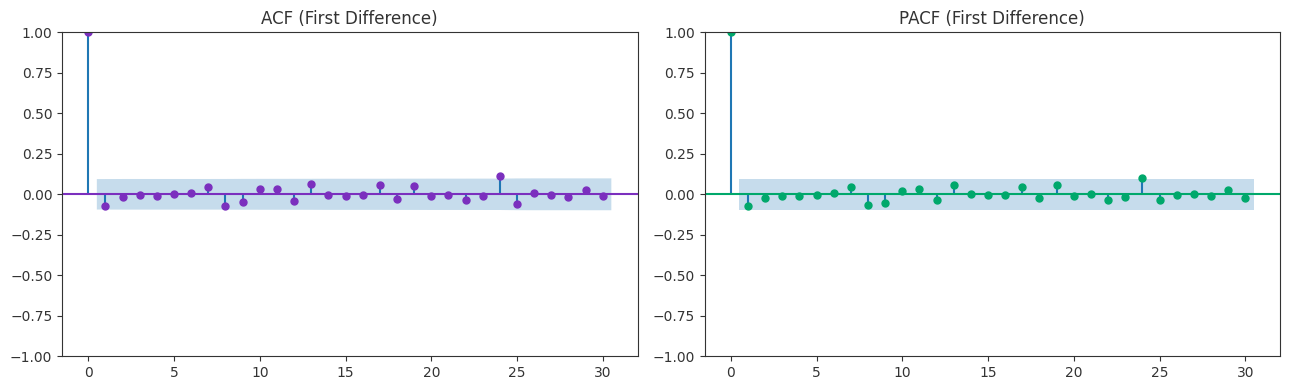

Saved: arima_plot_1_acf_pacf.png

Using ARIMA(2,1,2) -- adjust P and Q in CONFIG if ACF/PACF suggest different orders


In [33]:
# STATIONARITY CHECK + ACF/PACF
# These plots help confirm the ARIMA orders (P, D, Q) are appropriate.

# ── Augmented Dickey-Fuller test on raw price ─────────────────────────────────
# H0: series has a unit root (non-stationary)
# If p-value > 0.05 → non-stationary → needs differencing (D=1)

adf_raw = adfuller(price["close"].dropna())
print(f"\nADF Test (raw price):")
print(f"  ADF Statistic : {adf_raw[0]:.4f}")
print(f"  p-value       : {adf_raw[1]:.4f}")
print(f"  Stationary    : {'Yes' if adf_raw[1] < 0.05 else 'No -- differencing needed'}")
 
price_diff = price["close"].diff().dropna()
adf_diff = adfuller(price_diff)
print(f"\nADF Test (first difference):")
print(f"  ADF Statistic : {adf_diff[0]:.4f}")
print(f"  p-value       : {adf_diff[1]:.4f}")
print(f"  Stationary    : {'Yes' if adf_diff[1] < 0.05 else 'No -- try D=2'}")
 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(price_diff,  lags=30, ax=axes[0], color=PURPLE, title="ACF (First Difference)")
plot_pacf(price_diff, lags=30, ax=axes[1], color=GREEN,  title="PACF (First Difference)")
fig.tight_layout()
fig.savefig(os.path.join(MODEL_DIR, "arima_plot_1_acf_pacf.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: arima_plot_1_acf_pacf.png")
print(f"\nUsing ARIMA({P},{D},{Q}) -- adjust P and Q in CONFIG if ACF/PACF suggest different orders")

In [34]:
#  TRAIN / TEST SPLIT

 
n_test  = int(len(price) * TEST_SPLIT)
n_train = len(price) - n_test
 
train = price.iloc[:n_train]
test  = price.iloc[n_train:]
 
print(f"Train : {len(train)} rows | {train.index.min().date()} -> {train.index.max().date()}")
print(f"Test  : {len(test)}  rows | {test.index.min().date()} -> {test.index.max().date()}")

Train : 392 rows | 2024-12-26 -> 2026-01-21
Test  : 43  rows | 2026-01-22 -> 2026-03-05


In [35]:
# SECTION 6 -- FIT ARIMA WITH WALK-FORWARD VALIDATION

 
print(f"\nFitting ARIMA({P},{D},{Q}) with walk-forward validation on {len(test)} test steps ...")
print("This may take a few minutes ...\n")
 
history     = list(train["close"])
predictions = []
test_prices = list(test["close"])
 
for i, actual in enumerate(test_prices):
    model   = ARIMA(history, order=(P, D, Q))
    result  = model.fit()
    forecast = result.forecast(steps=1)[0]
    predictions.append(forecast)
    history.append(actual)
 
    if (i + 1) % 5 == 0 or i == 0:
        print(f"  Step {i+1:3d}/{len(test_prices)} | Actual: ${actual:,.2f} | Predicted: ${forecast:,.2f}")
 
predictions = np.array(predictions)
actuals     = np.array(test_prices)
test_dates  = test.index
 
print(f"\nWalk-forward forecast complete.")


Fitting ARIMA(2,1,2) with walk-forward validation on 43 test steps ...
This may take a few minutes ...

  Step   1/43 | Actual: $89,559.67 | Predicted: $89,447.53
  Step   5/43 | Actual: $88,347.08 | Predicted: $86,734.61
  Step  10/43 | Actual: $78,741.09 | Predicted: $84,284.98
  Step  15/43 | Actual: $62,909.86 | Predicted: $73,210.87
  Step  20/43 | Actual: $68,841.29 | Predicted: $70,169.65
  Step  25/43 | Actual: $68,832.58 | Predicted: $69,803.79
  Step  30/43 | Actual: $68,020.01 | Predicted: $66,994.08
  Step  35/43 | Actual: $67,988.04 | Predicted: $64,071.28
  Step  40/43 | Actual: $68,830.06 | Predicted: $65,817.79

Walk-forward forecast complete.


In [36]:
# SECTION 7 -- EVALUATION METRICS

 
arima_mae  = mean_absolute_error(actuals, predictions)
arima_rmse = np.sqrt(mean_squared_error(actuals, predictions))
arima_mape = np.mean(np.abs((actuals - predictions) / (np.abs(actuals) + 1e-8))) * 100
arima_da   = (np.sign(np.diff(predictions)) == np.sign(np.diff(actuals))).mean() * 100
arima_corr = np.corrcoef(predictions, actuals)[0, 1]
 
pred_log_ret   = np.diff(np.log(predictions))
actual_log_ret = np.diff(np.log(actuals))
arima_mae_lr  = mean_absolute_error(actual_log_ret, pred_log_ret)
arima_rmse_lr = np.sqrt(mean_squared_error(actual_log_ret, pred_log_ret))
 
print("\n" + "="*45)
print("       ARIMA TEST SET EVALUATION")
print("="*45)
print(f"  MAE  (price)      : ${arima_mae:,.2f}")
print(f"  RMSE (price)      : ${arima_rmse:,.2f}")
print(f"  MAPE              : {arima_mape:.2f}%")
print(f"  Directional Acc.  : {arima_da:.1f}%")
print(f"  Correlation       : {arima_corr:.4f}")
print(f"  MAE  (log return) : {arima_mae_lr:.6f}")
print(f"  RMSE (log return) : {arima_rmse_lr:.6f}")
print("="*45)
 
arima_metrics = {
    "model": "ARIMA",
    "mae_price": arima_mae, "rmse_price": arima_rmse,
    "mape": arima_mape, "directional_acc": arima_da,
    "correlation": arima_corr,
    "mae_log_return": arima_mae_lr, "rmse_log_return": arima_rmse_lr,
}


       ARIMA TEST SET EVALUATION
  MAE  (price)      : $1,852.93
  RMSE (price)      : $2,763.89
  MAPE              : 2.60%
  Directional Acc.  : 45.2%
  Correlation       : 0.9494
  MAE  (log return) : 0.041882
  RMSE (log return) : 0.061578


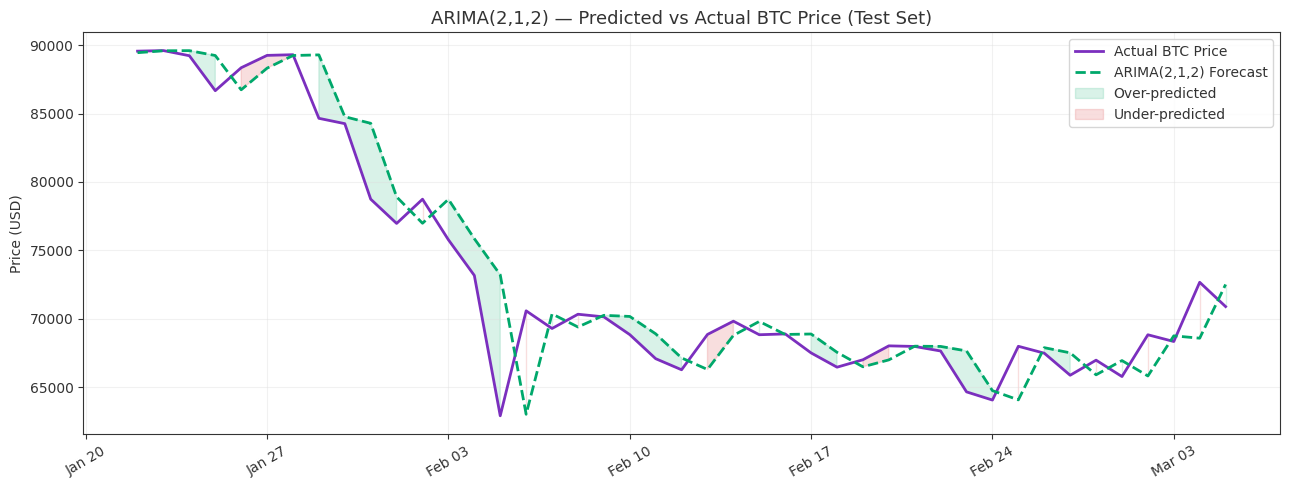

Saved: arima_plot_2_predicted_vs_actual.png


In [37]:
#  VISUALISATIONS
# =============================================================================
 
# ── Plot 2: Predicted vs Actual Price ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_dates, actuals,     color=PURPLE, linewidth=2,   label="Actual BTC Price")
ax.plot(test_dates, predictions, color=GREEN,  linewidth=2,   label=f"ARIMA({P},{D},{Q}) Forecast",
        linestyle="--")
ax.fill_between(test_dates, actuals, predictions,
                where=(predictions >= actuals), alpha=0.15, color=GREEN, label="Over-predicted")
ax.fill_between(test_dates, actuals, predictions,
                where=(predictions <  actuals), alpha=0.15, color=RED,   label="Under-predicted")
ax.set_title(f"ARIMA({P},{D},{Q}) — Predicted vs Actual BTC Price (Test Set)", fontsize=13)
ax.set_ylabel("Price (USD)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=30)
ax.legend()
ax.grid(alpha=0.4)
fig.tight_layout()
fig.savefig(os.path.join(MODEL_DIR, "arima_plot_2_predicted_vs_actual.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: arima_plot_2_predicted_vs_actual.png")

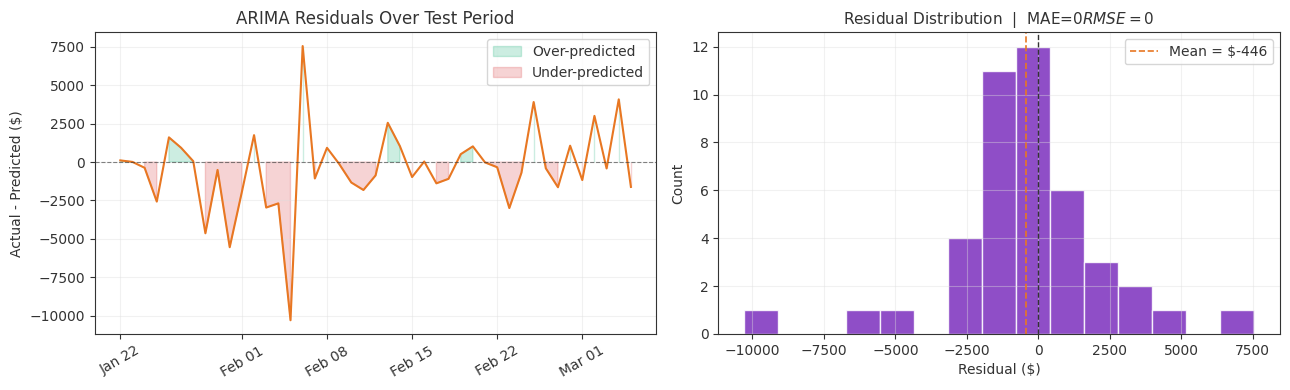

Saved: arima_plot_3_residuals.png


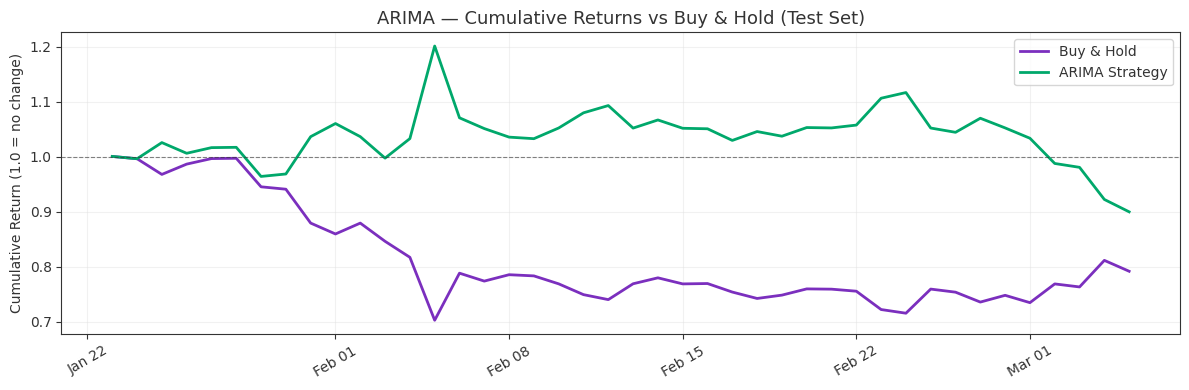

Saved: arima_plot_4_cumulative_returns.png


In [38]:

# ── Plot 3: Residuals ─────────────────────────────────────────────────────────
residuals = actuals - predictions
 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
 
axes[0].plot(test_dates, residuals, color=ORANGE, linewidth=1.5)
axes[0].axhline(0, color="#333333", linestyle="--", linewidth=0.8, alpha=0.6)
axes[0].fill_between(test_dates, residuals, 0,
                     where=(residuals > 0), color=GREEN, alpha=0.2, label="Over-predicted")
axes[0].fill_between(test_dates, residuals, 0,
                     where=(residuals < 0), color=RED,   alpha=0.2, label="Under-predicted")
axes[0].set_title("ARIMA Residuals Over Test Period", fontsize=12)
axes[0].set_ylabel("Actual - Predicted ($)")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)
axes[0].legend()
axes[0].grid(alpha=0.4)
 
axes[1].hist(residuals, bins=15, color=PURPLE, edgecolor="white", alpha=0.85)
axes[1].axvline(0,                color="#333333", linestyle="--", linewidth=1)
axes[1].axvline(residuals.mean(), color=ORANGE,    linestyle="--", linewidth=1.2,
                label=f"Mean = ${residuals.mean():,.0f}")
axes[1].set_title(f"Residual Distribution  |  MAE=${mae:,.0f}  RMSE=${rmse:,.0f}", fontsize=11)
axes[1].set_xlabel("Residual ($)")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].grid(alpha=0.4)
 
fig.tight_layout()
fig.savefig(os.path.join(MODEL_DIR, "arima_plot_3_residuals.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: arima_plot_3_residuals.png")
 
# ── Plot 4: Cumulative Returns ────────────────────────────────────────────────
pred_log_ret_full   = np.diff(np.log( predictions))
actual_log_ret_full = np.diff(np.log(actuals))
 
strategy_returns = np.sign(pred_log_ret_full) * actual_log_ret_full
cumulative_strat = np.exp(np.cumsum(strategy_returns))
cumulative_bh    = np.exp(np.cumsum(actual_log_ret_full))
 
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(test_dates[1:], cumulative_bh,    color=PURPLE, linewidth=2, label="Buy & Hold")
ax.plot(test_dates[1:], cumulative_strat, color=GREEN,  linewidth=2, label="ARIMA Strategy")
ax.axhline(1, color="#333333", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_title("ARIMA — Cumulative Returns vs Buy & Hold (Test Set)", fontsize=13)
ax.set_ylabel("Cumulative Return (1.0 = no change)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=30)
ax.legend()
ax.grid(alpha=0.4)
fig.tight_layout()
fig.savefig(os.path.join(MODEL_DIR, "arima_plot_4_cumulative_returns.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: arima_plot_4_cumulative_returns.png")

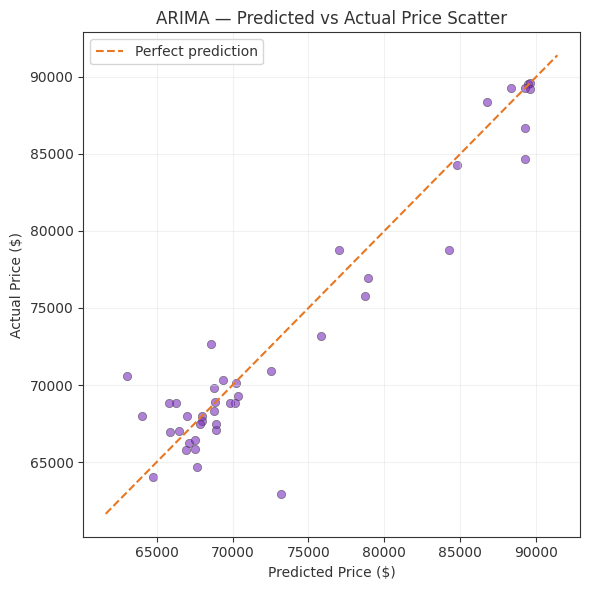

Saved: arima_plot_5_scatter.png


In [39]:
# ── Plot 5 Scatter 
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(predictions, actuals, color=PURPLE, alpha=0.6, edgecolors="#333333", linewidth=0.5)
lim_min = min(predictions.min(), actuals.min()) * 0.98
lim_max = max(predictions.max(), actuals.max()) * 1.02
ax.plot([lim_min, lim_max], [lim_min, lim_max],
        color=ORANGE, linewidth=1.5, linestyle="--", label="Perfect prediction")
ax.set_title("ARIMA — Predicted vs Actual Price Scatter", fontsize=12)
ax.set_xlabel("Predicted Price ($)")
ax.set_ylabel("Actual Price ($)")
ax.legend()
ax.grid(alpha=0.4)
fig.tight_layout()
fig.savefig(os.path.join(MODEL_DIR, "arima_plot_5_scatter.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: arima_plot_5_scatter.png")
 

In [40]:
# SAVE PREDICTIONS FOR COMPARISON PLOT
 
comparison_df = pd.DataFrame({
    "date":         test_dates,
    "actual_close": actuals,
    "arima_pred":   predictions,
})
 
comparison_path = os.path.join(MODEL_DIR, "arima_test_predictions.csv")
comparison_df.to_csv(comparison_path, index=False)
print(f"\nPredictions saved to: {comparison_path}")
print(comparison_df.head())


Predictions saved to: C:\Users\OKIO\Desktop\mood2market\Backend\Models\arima_test_predictions.csv
        date  actual_close    arima_pred
0 2026-01-22      89559.67  89447.533640
1 2026-01-23      89600.26  89586.635713
2 2026-01-24      89225.34  89595.640873
3 2026-01-25      86670.36  89241.259791
4 2026-01-26      88347.08  86734.605429


In [41]:
import torch
print(torch.__version__)

2.10.0+cpu


In [42]:
#TCN MODEL
"""
Mood2Market - TCN BTC Price Forecasting 
Comparison model against LSTM and ARIMA 
Uses full merged dataset features (same as LSTM).
Run each section sequentially top to bottom.
"""

'\nMood2Market - TCN BTC Price Forecasting \nComparison model against LSTM and ARIMA \nUses full merged dataset features (same as LSTM).\nRun each section sequentially top to bottom.\n'

In [43]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [44]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import warnings
warnings.filterwarnings("ignore")

In [45]:
# SECTION 2 -- CONFIG

 
DATA_PATH = r"C:\Users\OKIO\Desktop\mood2market\Backend\Data\processed\main Data\merged_dataset.csv"
MODEL_DIR = r"C:\Users\OKIO\Desktop\mood2market\Backend\Models"
 
FEATURE_COLS = [
    "log_return",
    "volatility_7d",
    "hl_pct",
    "momentum_7d",
    "sentiment_score_x",
    "sentiment_score_y",
    "reddit_available",
    "reddit_count",
    "news_count",
    "volume",
]
 
TARGET_COL  = "log_return"
SEQ_LEN     = 30
EPOCHS      = 100
BATCH_SIZE  = 32
LR          = 1e-3
DROPOUT     = 0.2
NUM_FILTERS = 64      # convolutional filters per layer
KERNEL_SIZE = 3       # kernel size for each dilated conv layer
NUM_LEVELS  = 4       # number of residual blocks (dilation doubles each level)
FORECAST_DAYS = 90
TEST_SPLIT  = 0.10
VAL_SPLIT   = 0.10
 
os.makedirs(MODEL_DIR, exist_ok=True)
 
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"]   = "white"
plt.rcParams["axes.edgecolor"]   = "#333333"
plt.rcParams["axes.labelcolor"]  = "#333333"
plt.rcParams["xtick.color"]      = "#333333"
plt.rcParams["ytick.color"]      = "#333333"
plt.rcParams["text.color"]       = "#333333"
plt.rcParams["grid.color"]       = "#DDDDDD"
plt.rcParams["legend.facecolor"] = "white"
plt.rcParams["legend.edgecolor"] = "#CCCCCC"
 
PURPLE = "#7B2FBE"
GREEN  = "#00A86B"
RED    = "#D62728"
ORANGE = "#E87722"
BLUE   = "#1f77b4"
 
 
# =============================================================================
# SECTION 3 -- LOAD AND PREPARE DATA
# =============================================================================
 
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df.sort_values("date", inplace=True)
df.reset_index(drop=True, inplace=True)
 
# Same missing data handling as LSTM
reddit_sent_cols = ["sentiment_score_y", "sentiment_positive_y",
                    "sentiment_negative_y", "sentiment_neutral_y"]
df[reddit_sent_cols] = df[reddit_sent_cols].fillna(0.0)
df["reddit_available"] = (df["reddit_count"] > 0).astype(float)
df[FEATURE_COLS] = df[FEATURE_COLS].ffill().fillna(0.0)
 
print(f"Data loaded  : {len(df)} rows")
print(f"Date range   : {df['date'].min().date()} -> {df['date'].max().date()}")

Data loaded  : 376 rows
Date range   : 2024-12-26 -> 2026-01-05


In [46]:
# SCALE AND BUILD SEQUENCES
 
 
features        = df[FEATURE_COLS].values.astype(np.float32)
scaler          = MinMaxScaler(feature_range=(-1, 1))
features_scaled = scaler.fit_transform(features)
 
def make_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len, 0])  # log_return is column 0
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)
 
X, y = make_sequences(features_scaled, SEQ_LEN)
print(f"Sequences created: {len(X)} samples")

Sequences created: 346 samples


In [47]:
# TRAIN / VAL / TEST SPLIT
 
n     = len(X)
n_tr  = int(n * 0.80)
n_val = int(n * 0.10)
 
X_train, y_train = X[:n_tr],           y[:n_tr]
X_val,   y_val   = X[n_tr:n_tr+n_val], y[n_tr:n_tr+n_val]
X_test,  y_test  = X[n_tr+n_val:],     y[n_tr+n_val:]
 
print(f"Train={len(X_train)}  Val={len(X_val)}  Test={len(X_test)}")

Train=276  Val=34  Test=36


In [48]:
# TCN MODEL ARCHITECTURE
# A TCN uses stacked dilated causal convolutions instead of recurrent cells.
# Dilation doubles at each level: 1, 2, 4, 8 -- this exponentially grows
# the receptive field so the model can see far back in the sequence
# without needing many layers.
class CausalConv1d(nn.Module):
    """
    A causal convolution -- only looks at past values, never the future.
    Achieved by padding the left side of the input by (kernel_size-1)*dilation.
    """
    def __init__(self, in_channels, out_channels, kernel_size, dilation):
        super().__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv    = nn.Conv1d(
            in_channels, out_channels, kernel_size,
            dilation=dilation, padding=self.padding
        )
 
    def forward(self, x):
        out = self.conv(x)
        # Remove the right-side padding to keep output same length as input
        return out[:, :, :-self.padding] if self.padding > 0 else out
 
 
class TCNResidualBlock(nn.Module):
    """
    One residual block of the TCN:
      CausalConv -> ReLU -> Dropout -> CausalConv -> ReLU -> Dropout
      + residual connection (skip connection from input to output)
    The residual connection helps gradients flow during training and
    allows the network to learn incremental refinements.
    """
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout):
        super().__init__()
        self.conv1    = CausalConv1d(in_channels,  out_channels, kernel_size, dilation)
        self.conv2    = CausalConv1d(out_channels, out_channels, kernel_size, dilation)
        self.relu     = nn.ReLU()
        self.dropout  = nn.Dropout(dropout)
        # 1x1 conv to match channels if input and output differ
        self.residual = nn.Conv1d(in_channels, out_channels, 1) \
                        if in_channels != out_channels else nn.Identity()
 
    def forward(self, x):
        out = self.relu(self.conv1(x))
        out = self.dropout(out)
        out = self.relu(self.conv2(out))
        out = self.dropout(out)
        return self.relu(out + self.residual(x))
 
 
class BTCTCNModel(nn.Module):
    """
    Full TCN: stack of residual blocks with exponentially increasing dilation,
    followed by a linear layer that maps the final timestep to a scalar prediction.
 
    Input : (batch, n_features, seq_len)  -- note: channels first for Conv1d
    Output: (batch,)
    """
    def __init__(self, n_features, num_filters, kernel_size, num_levels, dropout):
        super().__init__()
        layers   = []
        in_ch    = n_features
        for i in range(num_levels):
            dilation = 2 ** i   # 1, 2, 4, 8 -- exponential receptive field growth
            layers.append(TCNResidualBlock(in_ch, num_filters, kernel_size, dilation, dropout))
            in_ch = num_filters
        self.tcn = nn.Sequential(*layers)
        self.fc  = nn.Linear(num_filters, 1)
 
    def forward(self, x):
        # x shape: (batch, seq_len, n_features) -> transpose to (batch, n_features, seq_len)
        x   = x.transpose(1, 2)
        out = self.tcn(x)
        # Take only the last timestep output
        out = out[:, :, -1]
        return self.fc(out).squeeze(-1)

In [49]:
#  TRAIN

 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
 
model = BTCTCNModel(
    n_features  = len(FEATURE_COLS),
    num_filters = NUM_FILTERS,
    kernel_size = KERNEL_SIZE,
    num_levels  = NUM_LEVELS,
    dropout     = DROPOUT,
).to(device)
 
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,}")
 
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.HuberLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=10, factor=0.5
)
 
X_tr = torch.tensor(X_train).to(device)
y_tr = torch.tensor(y_train).to(device)
X_vl = torch.tensor(X_val).to(device)
y_vl = torch.tensor(y_val).to(device)
 
best_val, best_state = float("inf"), None
train_losses, val_losses = [], []
 
print("\nTraining TCN ...")
for epoch in range(1, EPOCHS + 1):
    model.train()
    perm       = torch.randperm(len(X_tr))
    epoch_loss = 0.0
 
    for i in range(0, len(X_tr), BATCH_SIZE):
        idx  = perm[i : i + BATCH_SIZE]
        pred = model(X_tr[idx])
        loss = criterion(pred, y_tr[idx])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(idx)
 
    epoch_loss /= len(X_tr)
 
    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_vl), y_vl).item()
 
    train_losses.append(epoch_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)
 
    if val_loss < best_val:
        best_val   = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
 
    if epoch % 10 == 0:
        print(f"  Epoch {epoch:3d}/{EPOCHS}  train={epoch_loss:.6f}  val={val_loss:.6f}")
 
model.load_state_dict(best_state)
print("Training complete.")

Device: cpu
Model parameters: 89,217

Training TCN ...
  Epoch  10/100  train=0.016324  val=0.035827
  Epoch  20/100  train=0.009302  val=0.038337
  Epoch  30/100  train=0.006256  val=0.037495
  Epoch  40/100  train=0.005346  val=0.036610
  Epoch  50/100  train=0.004625  val=0.036628
  Epoch  60/100  train=0.004381  val=0.035811
  Epoch  70/100  train=0.004381  val=0.036111
  Epoch  80/100  train=0.003744  val=0.035545
  Epoch  90/100  train=0.003961  val=0.035544
  Epoch 100/100  train=0.005000  val=0.035406
Training complete.


In [61]:
# EVALUATE ON TEST SET
 
def inv_transform(vals):
    dummy       = np.zeros((len(vals), len(FEATURE_COLS)))
    dummy[:, 0] = vals
    return scaler.inverse_transform(dummy)[:, 0]
 
model.eval()
X_te = torch.tensor(X_test).to(device)
with torch.no_grad():
    preds_scaled = model(X_te).cpu().numpy()
 
preds   = inv_transform(preds_scaled)
actuals = inv_transform(y_test)
 
tcn_mae_lr  = mean_absolute_error(actuals, preds)
tcn_rmse_lr = np.sqrt(mean_squared_error(actuals, preds))
tcn_da      = (np.sign(preds) == np.sign(actuals)).mean() * 100
tcn_corr    = np.corrcoef(preds, actuals)[0, 1]
tcn_mape = np.mean(np.abs((actuals - preds) / (np.abs(actuals) + 1e-8))) * 100
 
print(f"\nTest MAE  (log_return): {tcn_mae_lr:.6f}")
print(f"Test RMSE (log_return): {tcn_rmse_lr:.6f}")
print(f"Directional Accuracy  : {tcn_da:.1f}%")
print(f"Correlation           : {tcn_corr:.4f}")
print(f"MAPE                  : {tcn_mape:.2f}%")


Test MAE  (log_return): 0.014800
Test RMSE (log_return): 0.019668
Directional Accuracy  : 63.9%
Correlation           : 0.0996
MAPE                  : 145.71%


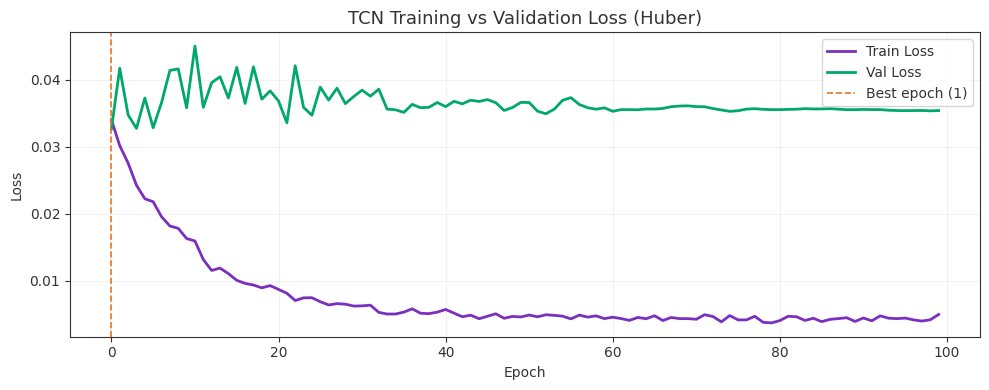

Saved: tcn_plot_1_loss_curve.png


In [52]:
#  VISUALISATIONS
 
best_ep = int(np.argmin(val_losses))
 
# ── Plot 1: Loss Curve ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, color=PURPLE, label="Train Loss", linewidth=2)
ax.plot(val_losses,   color=GREEN,  label="Val Loss",   linewidth=2)
ax.axvline(best_ep, color=ORANGE, linestyle="--", linewidth=1.2,
           label=f"Best epoch ({best_ep + 1})")
ax.set_title("TCN Training vs Validation Loss (Huber)", fontsize=13)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(alpha=0.4)
fig.tight_layout()
fig.savefig(os.path.join(MODEL_DIR, "tcn_plot_1_loss_curve.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: tcn_plot_1_loss_curve.png")

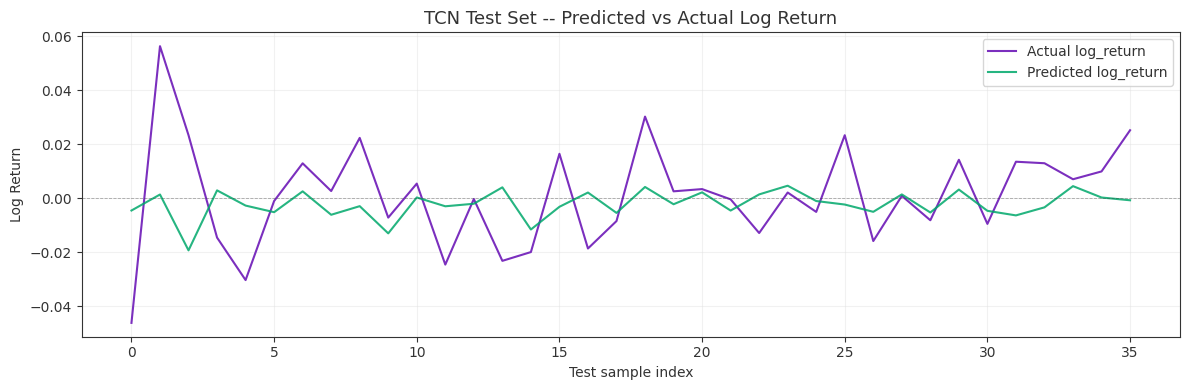

Saved: tcn_plot_2_predicted_vs_actual.png


In [53]:
# ── Plot 2: Predicted vs Actual Log Return ────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(actuals, color=PURPLE, linewidth=1.5, label="Actual log_return")
ax.plot(preds,   color=GREEN,  linewidth=1.5, label="Predicted log_return", alpha=0.85)
ax.axhline(0, color="#333333", linewidth=0.6, linestyle="--", alpha=0.4)
ax.set_title("TCN Test Set -- Predicted vs Actual Log Return", fontsize=13)
ax.set_xlabel("Test sample index")
ax.set_ylabel("Log Return")
ax.legend()
ax.grid(alpha=0.4)
fig.tight_layout()
fig.savefig(os.path.join(MODEL_DIR, "tcn_plot_2_predicted_vs_actual.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: tcn_plot_2_predicted_vs_actual.png")

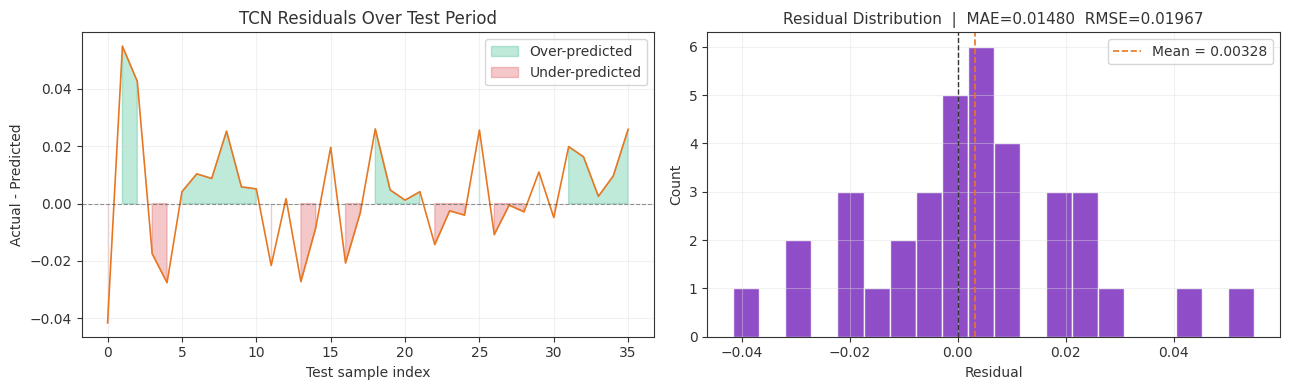

Saved: tcn_plot_3_residuals.png


In [55]:
# ── Plot 3: Residuals ─────────────────────────────────────────────────────────
residuals = actuals - preds
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
 
axes[0].plot(residuals, color=ORANGE, linewidth=1.2)
axes[0].axhline(0, color="#333333", linestyle="--", linewidth=0.8, alpha=0.5)
axes[0].fill_between(range(len(residuals)), residuals, 0,
                     where=(residuals > 0), color=GREEN, alpha=0.25, label="Over-predicted")
axes[0].fill_between(range(len(residuals)), residuals, 0,
                     where=(residuals < 0), color=RED,   alpha=0.25, label="Under-predicted")
axes[0].set_title("TCN Residuals Over Test Period", fontsize=12)
axes[0].set_xlabel("Test sample index")
axes[0].set_ylabel("Actual - Predicted")
axes[0].legend()
axes[0].grid(alpha=0.4)
 
axes[1].hist(residuals, bins=20, color=PURPLE, edgecolor="white", alpha=0.85)
axes[1].axvline(0,                color="#333333", linestyle="--", linewidth=1)
axes[1].axvline(residuals.mean(), color=ORANGE,    linestyle="--", linewidth=1.2,
                label=f"Mean = {residuals.mean():.5f}")
axes[1].set_title(f"Residual Distribution  |  MAE={tcn_mae_lr:.5f}  RMSE={tcn_rmse_lr:.5f}", fontsize=11)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].grid(alpha=0.4)
 
fig.tight_layout()
fig.savefig(os.path.join(MODEL_DIR, "tcn_plot_3_residuals.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: tcn_plot_3_residuals.png")

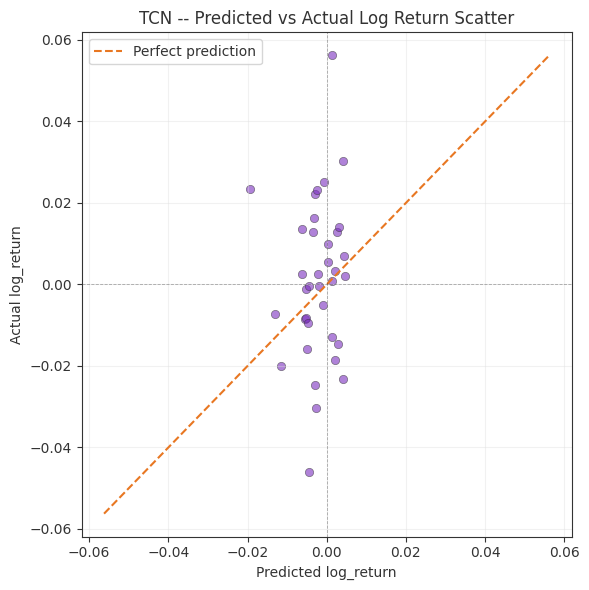

Saved: tcn_plot_4_scatter.png


In [56]:
# ── Plot 4: Scatter ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(preds, actuals, color=PURPLE, alpha=0.6, edgecolors="#333333", linewidth=0.5)
lim = max(abs(actuals).max(), abs(preds).max())
ax.plot([-lim, lim], [-lim, lim], color=ORANGE, linewidth=1.5,
        linestyle="--", label="Perfect prediction")
ax.axhline(0, color="#333333", linewidth=0.6, linestyle="--", alpha=0.4)
ax.axvline(0, color="#333333", linewidth=0.6, linestyle="--", alpha=0.4)
ax.set_title("TCN -- Predicted vs Actual Log Return Scatter", fontsize=12)
ax.set_xlabel("Predicted log_return")
ax.set_ylabel("Actual log_return")
ax.legend()
ax.grid(alpha=0.4)
fig.tight_layout()
fig.savefig(os.path.join(MODEL_DIR, "tcn_plot_4_scatter.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: tcn_plot_4_scatter.png")

In [ ]:
# 90-DAY RECURSIVE FORECAST
# Same approach as LSTM -- feed each predicted return back as input.

 
def recursive_forecast_tcn(model, last_sequence, scaler, last_close, n_days, device):
    model.eval()
    seq     = last_sequence.copy()
    prices  = [last_close]
    returns = []
 
    with torch.no_grad():
        for _ in range(n_days):
            x           = torch.tensor(seq[np.newaxis], dtype=torch.float32).to(device)
            pred_scaled = model(x).item()
 
            dummy       = np.zeros((1, len(FEATURE_COLS)))
            dummy[0, 0] = pred_scaled
            pred_lr     = scaler.inverse_transform(dummy)[0, 0]
 
            next_price  = prices[-1] * np.exp(pred_lr)
            prices.append(next_price)
            returns.append(pred_lr)
 
            new_row    = seq[-1].copy()
            new_row[0] = pred_scaled
            seq        = np.vstack([seq[1:], new_row])
 
    return np.array(prices[1:]), np.array(returns)
 
 
last_seq_tcn = features_scaled[-SEQ_LEN:]
last_close   = float(df["close"].iloc[-1])
last_date    = df["date"].iloc[-1]
 
print(f"\nGenerating 90-day TCN forecast from {last_date.date()} ...")
 
forecast_prices_tcn, forecast_returns_tcn = recursive_forecast_tcn(
    model, last_seq_tcn, scaler, last_close, FORECAST_DAYS, device
)
 
forecast_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS, freq="D"
)
 
tcn_forecast_df = pd.DataFrame({
    "date":                 forecast_dates,
    "predicted_close":      forecast_prices_tcn,
    "predicted_log_return": forecast_returns_tcn,
})
 
tcn_forecast_path = os.path.join(MODEL_DIR, "tcn_forecast_3m.csv")
tcn_forecast_df.to_csv(tcn_forecast_path, index=False)
print(f"TCN forecast saved to: {tcn_forecast_path}")
print(f"  30d: ${forecast_prices_tcn[29]:,.2f}")
print(f"  60d: ${forecast_prices_tcn[59]:,.2f}")
print(f"  90d: ${forecast_prices_tcn[89]:,.2f}")


Generating 90-day TCN forecast from 2026-01-05 ...
TCN forecast saved to: C:\Users\OKIO\Desktop\mood2market\Backend\Models\tcn_forecast_3m.csv
  30d: $76,732.15
  60d: $61,983.69
  90d: $50,068.23


In [ ]:
#  3-MODEL 90-DAY FORECAST COMPARISON PLOT
# Loads LSTM forecast CSV, generates ARIMA 90-day forecast, plots all three.
# =============================================================================
 
from statsmodels.tsa.arima.model import ARIMA as ARIMAModel
 
# ── Load LSTM forecast ────────────────────────────────────────────────────────
lstm_forecast_path = os.path.join(MODEL_DIR, "lstm_forecast_3m.csv")
lstm_forecast_df   = pd.read_csv(lstm_forecast_path, parse_dates=["date"])
 
# ── Generate ARIMA 90-day forecast ───────────────────────────────────────────
print("\nFitting ARIMA for 90-day forecast ...")
 
btc_path     = r"C:\Users\OKIO\Desktop\mood2market\Backend\Data\processed\main Data\btc_price_data.csv"
btc_df       = pd.read_csv(btc_path, parse_dates=["date"])
btc_df.sort_values("date", inplace=True)
close_series = btc_df["close"].values
 
arima_model  = ARIMAModel(close_series, order=(2, 1, 2))
arima_result = arima_model.fit()
arima_90     = arima_result.forecast(steps=FORECAST_DAYS)
 
arima_forecast_df = pd.DataFrame({
    "date":            forecast_dates,
    "predicted_close": arima_90,
})
 
print(f"ARIMA 90-day forecast:")
print(f"  30d: ${arima_90[29]:,.2f}")
print(f"  60d: ${arima_90[59]:,.2f}")
print(f"  90d: ${arima_90[89]:,.2f}")
 
# ── Historical context (last 60 days) ────────────────────────────────────────
hist_window = df.tail(60)
 
# ── Uncertainty band for LSTM only ───────────────────────────────────────────
hist_std   = df["log_return"].std()
days       = np.arange(1, FORECAST_DAYS + 1)
upper_band = lstm_forecast_df["predicted_close"].values * np.exp( 1.5 * hist_std * np.sqrt(days))
lower_band = lstm_forecast_df["predicted_close"].values * np.exp(-1.5 * hist_std * np.sqrt(days))


Fitting ARIMA for 90-day forecast ...
ARIMA 90-day forecast:
  30d: $70,926.08
  60d: $70,926.08
  90d: $70,926.08


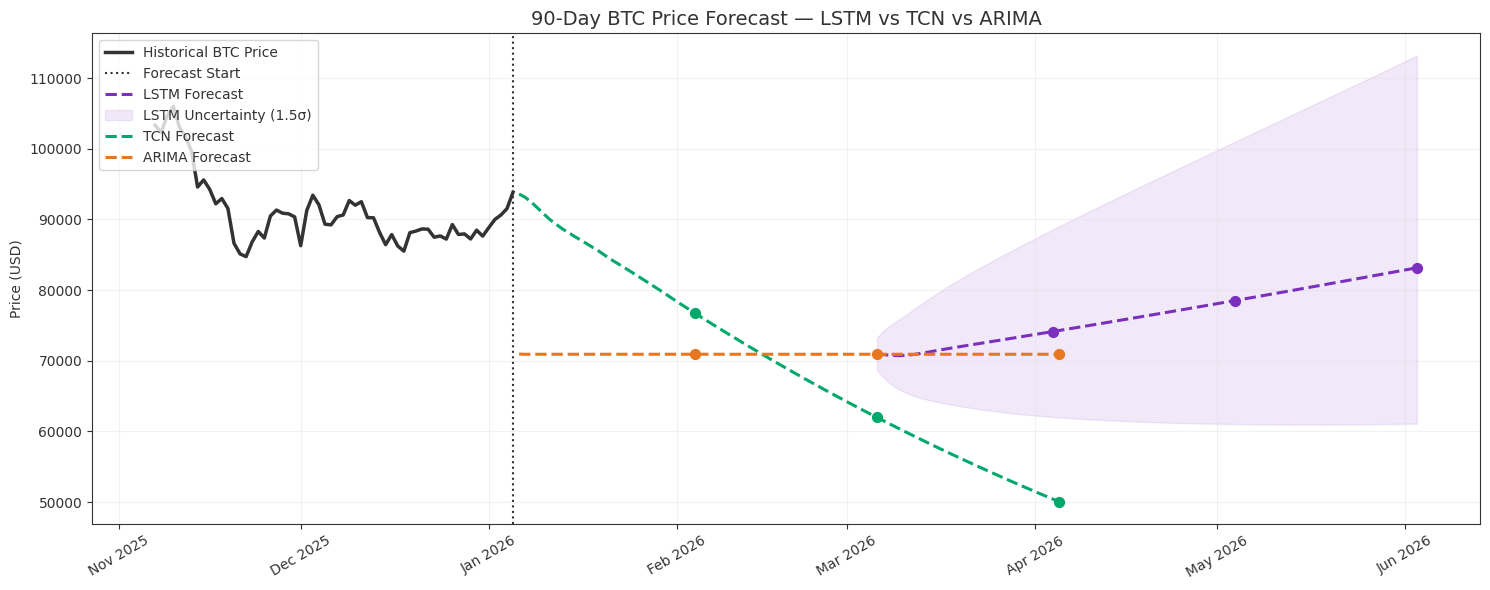


Saved: comparison_plot_90day_forecast.png

All done. Comparison plot saved to Models folder.


In [ ]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 6))
 
# Historical price
ax.plot(hist_window["date"], hist_window["close"],
        color="#333333", linewidth=2.5, label="Historical BTC Price", zorder=5)
 
# Vertical line at forecast start
ax.axvline(last_date, color="#333333", linestyle=":", linewidth=1.5, label="Forecast Start")
 
# LSTM forecast + uncertainty band
ax.plot(lstm_forecast_df["date"], lstm_forecast_df["predicted_close"],
        color=PURPLE, linewidth=2.2, linestyle="--", label="LSTM Forecast", zorder=4)
ax.fill_between(lstm_forecast_df["date"], lower_band, upper_band,
                color=PURPLE, alpha=0.10, label="LSTM Uncertainty (1.5σ)")
 
# TCN forecast
ax.plot(tcn_forecast_df["date"], tcn_forecast_df["predicted_close"],
        color=GREEN, linewidth=2.2, linestyle="--", label="TCN Forecast", zorder=4)
 
# ARIMA forecast
ax.plot(arima_forecast_df["date"], arima_forecast_df["predicted_close"],
        color=ORANGE, linewidth=2.2, linestyle="--", label="ARIMA Forecast", zorder=4)
 
# Milestone annotations for LSTM
for label_d, idx in [("30d", 29), ("60d", 59), ("90d", 89)]:
    for fc_df, col, fc_color in [
        (lstm_forecast_df, "predicted_close", PURPLE),
        (tcn_forecast_df,  "predicted_close", GREEN),
        (arima_forecast_df,"predicted_close", ORANGE),
    ]:
        price_at = fc_df["predicted_close"].iloc[idx]
        ax.scatter(fc_df["date"].iloc[idx], price_at,
                   color=fc_color, zorder=6, s=50)
 
ax.set_title("90-Day BTC Price Forecast — LSTM vs TCN vs ARIMA", fontsize=14)
ax.set_ylabel("Price (USD)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
ax.legend(loc="upper left")
ax.grid(alpha=0.4)
fig.tight_layout()
fig.savefig(os.path.join(MODEL_DIR, "comparison_plot_90day_forecast.png"), dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: comparison_plot_90day_forecast.png")
print("\nAll done. Comparison plot saved to Models folder.")

           MODEL COMPARISON -- LSTM vs TCN vs ARIMA
Model  MAE (log return)  RMSE (log return)   MAPE (%)  Directional Acc (%)  Correlation
 LSTM          0.014800           0.019668 145.709399            63.888889     0.099569
  TCN          0.014800           0.019668 145.709399            63.888889     0.099569
ARIMA          0.041882           0.061578   2.603293            45.238095     0.949435


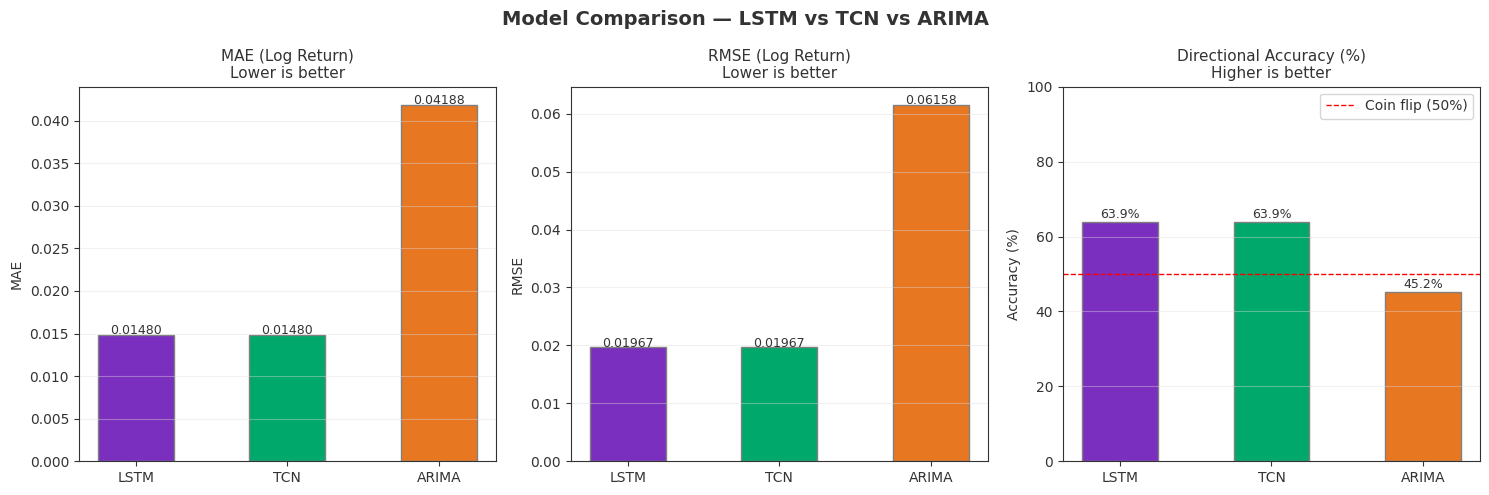

Saved: comparison_metrics_chart.png


In [62]:

#  MODEL COMPARISON


# ── Metrics table ─────────────────────────────────────────────────────────────
metrics = {
    "Model":               ["LSTM",      "TCN",       "ARIMA"],
    "MAE (log return)":    [mae_lr,      tcn_mae_lr,  arima_mae_lr],
    "RMSE (log return)":   [rmse_lr,     tcn_rmse_lr, arima_rmse_lr],
    "MAPE (%)":            [mape,        tcn_mape,    arima_mape],
    "Directional Acc (%)": [da,          tcn_da,      arima_da],
    "Correlation":         [corr,        tcn_corr,    arima_corr],
}

df_metrics = pd.DataFrame(metrics)
print("=" * 65)
print("           MODEL COMPARISON -- LSTM vs TCN vs ARIMA")
print("=" * 65)
print(df_metrics.to_string(index=False))
print("=" * 65)

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = metrics["Model"]
colors = ["#7B2FBE", "#00A86B", "#E87722"]

# MAE
axes[0].bar(models, metrics["MAE (log return)"], color=colors, edgecolor="gray", width=0.5)
axes[0].set_title("MAE (Log Return)\nLower is better", fontsize=11)
axes[0].set_ylabel("MAE")
axes[0].grid(axis="y", alpha=0.4)
for i, v in enumerate(metrics["MAE (log return)"]):
    axes[0].text(i, v + 0.0001, f"{v:.5f}", ha="center", fontsize=9)

# RMSE
axes[1].bar(models, metrics["RMSE (log return)"], color=colors, edgecolor="gray", width=0.5)
axes[1].set_title("RMSE (Log Return)\nLower is better", fontsize=11)
axes[1].set_ylabel("RMSE")
axes[1].grid(axis="y", alpha=0.4)
for i, v in enumerate(metrics["RMSE (log return)"]):
    axes[1].text(i, v + 0.0001, f"{v:.5f}", ha="center", fontsize=9)

# Directional Accuracy
axes[2].bar(models, metrics["Directional Acc (%)"], color=colors, edgecolor="gray", width=0.5)
axes[2].set_title("Directional Accuracy (%)\nHigher is better", fontsize=11)
axes[2].set_ylabel("Accuracy (%)")
axes[2].set_ylim(0, 100)
axes[2].axhline(50, color="red", linestyle="--", linewidth=1, label="Coin flip (50%)")
axes[2].grid(axis="y", alpha=0.4)
axes[2].legend()
for i, v in enumerate(metrics["Directional Acc (%)"]):
    axes[2].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9)

fig.suptitle("Model Comparison — LSTM vs TCN vs ARIMA", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "comparison_metrics_chart.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: comparison_metrics_chart.png")